##### Combined Section 7 Comparison Across Datasets

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('default')
results_dir = Path('results')
results_dir.mkdir(exist_ok=True)

records = [
    # Books
    {'Dataset': 'Books', 'Model': 'MLP Two Tower', 'NDCG@20': 0.009611, 'Recall@20': 0.010848, 'TrainingTimeSec': 711.283068},
    {'Dataset': 'Books', 'Model': 'LightGCN', 'NDCG@20': 0.028020, 'Recall@20': 0.033102, 'TrainingTimeSec': 1111.985590},
    {'Dataset': 'Books', 'Model': 'LightGCL', 'NDCG@20': 0.024468, 'Recall@20': 0.027774, 'TrainingTimeSec': 113.367430},
    {'Dataset': 'Books', 'Model': 'GATv2', 'NDCG@20': 0.023156, 'Recall@20': 0.027752, 'TrainingTimeSec': 1726.982008},
    {'Dataset': 'Books', 'Model': 'GraphSAGE', 'NDCG@20': 0.022702, 'Recall@20': 0.026528, 'TrainingTimeSec': 913.342793},
    {'Dataset': 'Books', 'Model': 'SVD Graph Fusion', 'NDCG@20': 0.027786, 'Recall@20': 0.032713, 'TrainingTimeSec': 1503.302577},

    # Electronics
    {'Dataset': 'Electronics', 'Model': 'MLP Two Tower', 'NDCG@20': 0.026415, 'Recall@20': 0.040330, 'TrainingTimeSec': 321.460037},
    {'Dataset': 'Electronics', 'Model': 'LightGCN', 'NDCG@20': 0.029027, 'Recall@20': 0.049410, 'TrainingTimeSec': 501.025296},
    {'Dataset': 'Electronics', 'Model': 'LightGCL', 'NDCG@20': 0.031289, 'Recall@20': 0.053249, 'TrainingTimeSec': 213.195711},
    {'Dataset': 'Electronics', 'Model': 'GATv2', 'NDCG@20': 0.028990, 'Recall@20': 0.042292, 'TrainingTimeSec': 438.897725},
    {'Dataset': 'Electronics', 'Model': 'GraphSAGE', 'NDCG@20': 0.026185, 'Recall@20': 0.042360, 'TrainingTimeSec': 313.464777},
    {'Dataset': 'Electronics', 'Model': 'SVD Graph Fusion', 'NDCG@20': 0.030085, 'Recall@20': 0.050787, 'TrainingTimeSec': 1106.171383},

    # Music Instruments
    {'Dataset': 'Music Instruments', 'Model': 'MLP Two Tower', 'NDCG@20': 0.027179, 'Recall@20': 0.052447, 'TrainingTimeSec': 333.106931},
    {'Dataset': 'Music Instruments', 'Model': 'LightGCN', 'NDCG@20': 0.031780, 'Recall@20': 0.070845, 'TrainingTimeSec': 652.539867},
    {'Dataset': 'Music Instruments', 'Model': 'LightGCL', 'NDCG@20': 0.031511, 'Recall@20': 0.067309, 'TrainingTimeSec': 909.213701},
    {'Dataset': 'Music Instruments', 'Model': 'GATv2', 'NDCG@20': 0.022307, 'Recall@20': 0.045768, 'TrainingTimeSec': 249.507937},
    {'Dataset': 'Music Instruments', 'Model': 'GraphSAGE', 'NDCG@20': 0.027151, 'Recall@20': 0.050161, 'TrainingTimeSec': 258.646044},
    {'Dataset': 'Music Instruments', 'Model': 'SVD Graph Fusion', 'NDCG@20': 0.033291, 'Recall@20': 0.072619, 'TrainingTimeSec': 1438.658766},
]

comparison_df = pd.DataFrame(records)
comparison_df

,Dataset,Model,NDCG@20,Recall@20,TrainingTimeSec
0,Books,MLP Two Tower,0.009611,0.010848,711.283068
1,Books,LightGCN,0.028020,0.033102,1111.985590
2,Books,LightGCL,0.024468,0.027774,113.367430
3,Books,GATv2,0.023156,0.027752,1726.982008
4,Books,GraphSAGE,0.022702,0.026528,913.342793
5,Books,SVD Graph Fusion,0.027786,0.032713,1503.302577
6,Electronics,MLP Two Tower,0.026415,0.040330,321.460037
7,Electronics,LightGCN,0.029027,0.049410,501.025296
8,Electronics,LightGCL,0.031289,0.053249,213.195711
9,Electronics,GATv2,0.028990,0.042292,438.897725


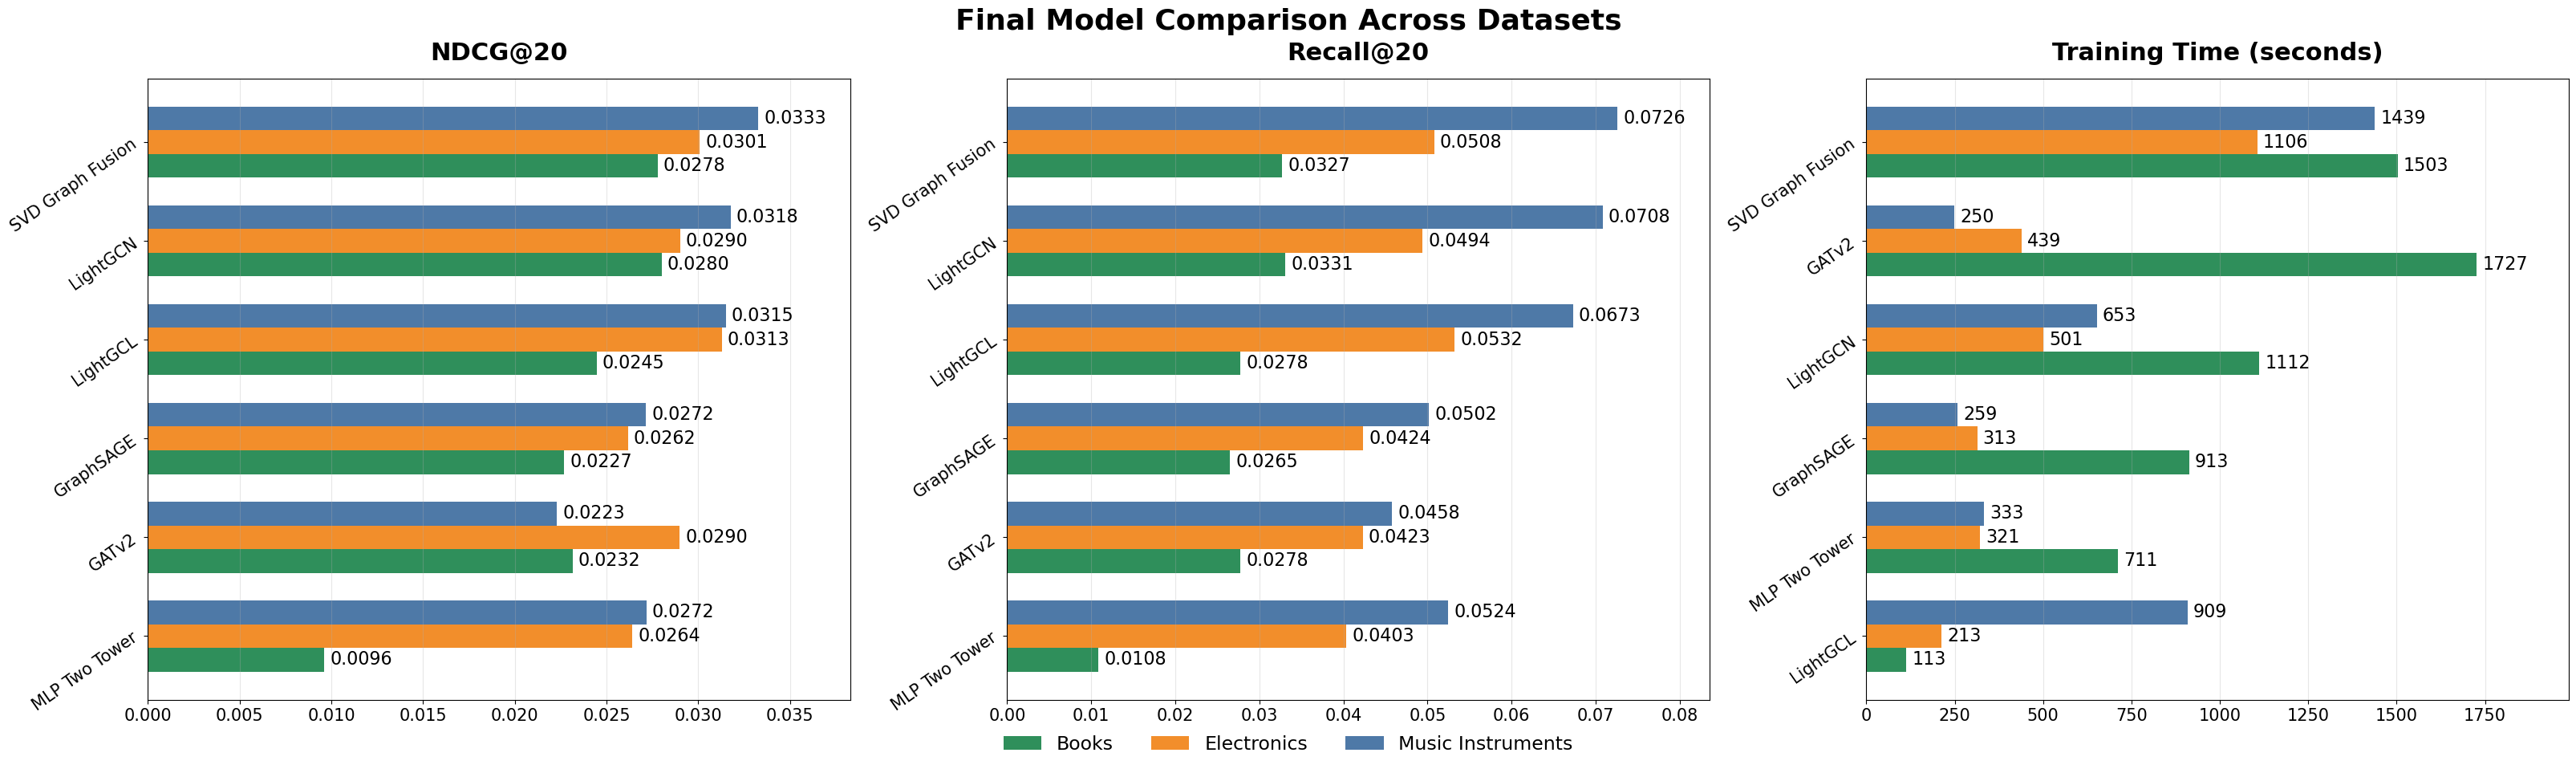

In [39]:
datasets = ['Books', 'Electronics', 'Music Instruments']
colors = {
    'Books': '#2f8f5b',
    'Electronics': '#f28e2b',
    'Music Instruments': '#4e79a7',
}

def plot_grouped_metric(ax, df, metric, title, value_format):
    model_order = (
        df.groupby('Model')[metric]
        .mean()
        .sort_values(ascending=True)
        .index
        .tolist()
    )
    y = np.arange(len(model_order))
    bar_height = 0.24
    offsets = np.linspace(-bar_height, bar_height, len(datasets))

    for dataset, offset in zip(datasets, offsets):
        values = (
            df[df['Dataset'] == dataset]
            .set_index('Model')
            .reindex(model_order)[metric]
        )
        bars = ax.barh(y + offset, values, height=bar_height, color=colors[dataset], label=dataset)
        ax.bar_label(bars, labels=[value_format.format(v) for v in values], padding=5, fontsize=16)

    ax.set_yticks(y)
    ax.set_yticklabels(model_order, rotation=35, ha='right', fontsize=15)
    ax.set_title(title, fontsize=22, fontweight='bold', pad=16)
    ax.tick_params(axis='x', labelsize=15)
    ax.grid(axis='x', alpha=0.3)
    ax.margins(x=0.15)


fig, axes = plt.subplots(1, 3, figsize=(32, 9), constrained_layout=True)
plot_grouped_metric(axes[0], comparison_df, 'NDCG@20', 'NDCG@20', '{:.4f}')
plot_grouped_metric(axes[1], comparison_df, 'Recall@20', 'Recall@20', '{:.4f}')
plot_grouped_metric(axes[2], comparison_df, 'TrainingTimeSec', 'Training Time (seconds)', '{:.0f}')

fig.suptitle('Final Model Comparison Across Datasets', fontsize=26, fontweight='bold')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.06), fontsize=17)
fig.savefig(results_dir / 'final_model_comparison_across_datasets.pdf', bbox_inches='tight', dpi=600)
fig.savefig(results_dir / 'final_model_comparison_across_datasets.png', bbox_inches='tight', dpi=600)
plt.show()

##### Dataset-Grouped Model Comparison

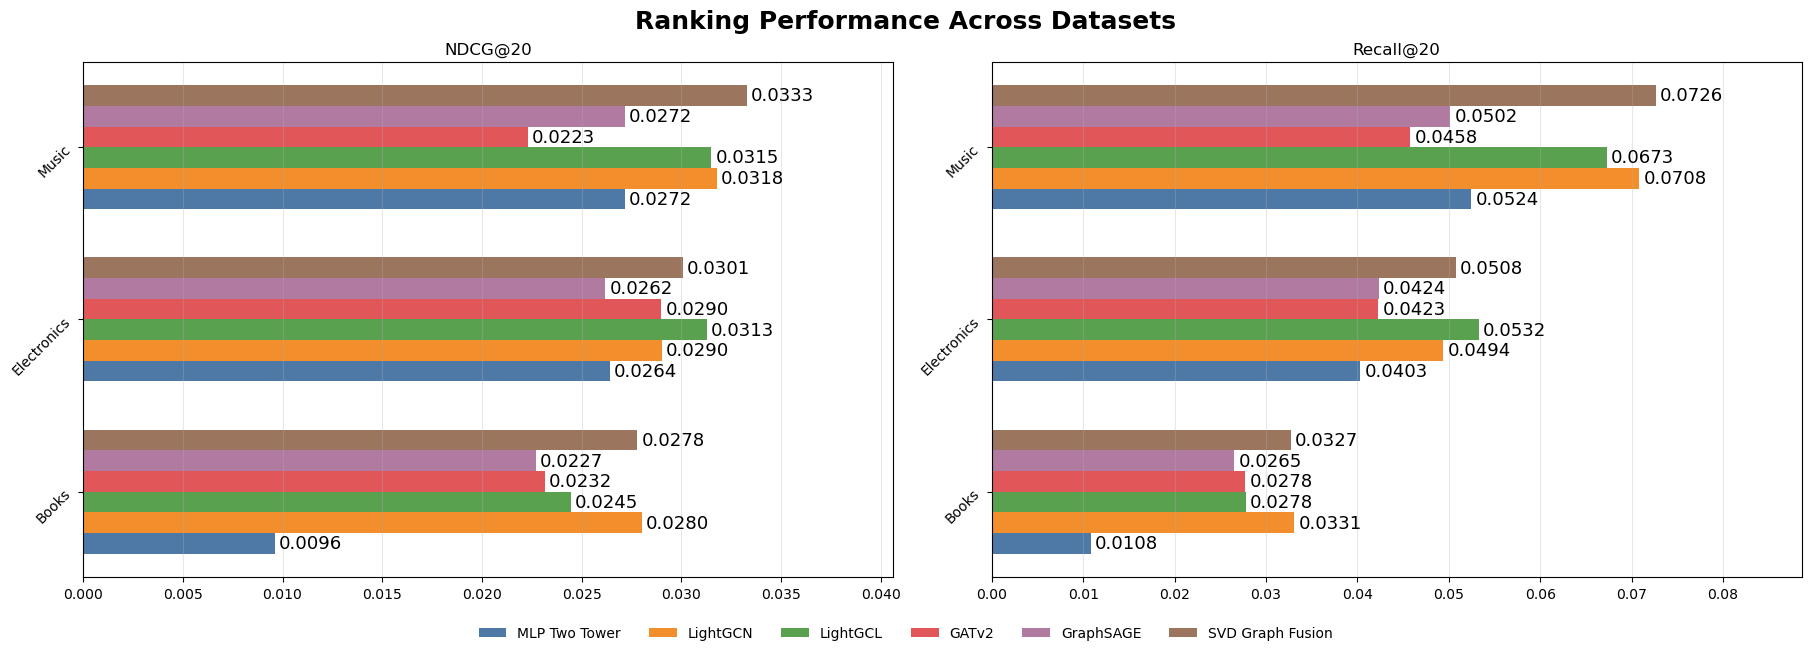

In [40]:
models = [
    'MLP Two Tower',
    'LightGCN',
    'LightGCL',
    'GATv2',
    'GraphSAGE',
    'SVD Graph Fusion',
]
model_colors = {
    'MLP Two Tower': '#4e79a7',
    'LightGCN': '#f28e2b',
    'LightGCL': '#59a14f',
    'GATv2': '#e15759',
    'GraphSAGE': '#b07aa1',
    'SVD Graph Fusion': '#9c755f',
}
dataset_labels = {
    'Books': 'Books',
    'Electronics': 'Electronics',
    'Music Instruments': 'Music',
}

def plot_dataset_grouped_bars(ax, df, metric, title, value_format):
    y = np.arange(len(datasets))
    bar_height = 0.12
    offsets = (np.arange(len(models)) - (len(models) - 1) / 2) * bar_height

    for model, offset in zip(models, offsets):
        values = (
            df[df['Model'] == model]
            .set_index('Dataset')
            .reindex(datasets)[metric]
        )
        bars = ax.barh(y + offset, values, height=bar_height, color=model_colors[model], label=model)
        ax.bar_label(bars, labels=[value_format.format(v) for v in values], padding=3, fontsize=13)

    ax.set_yticks(y)
    ax.set_yticklabels([dataset_labels[dataset] for dataset in datasets], rotation=45, ha='right')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.3)
    ax.margins(x=0.22)


fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
plot_dataset_grouped_bars(axes[0], comparison_df, 'NDCG@20', 'NDCG@20', '{:.4f}')
plot_dataset_grouped_bars(axes[1], comparison_df, 'Recall@20', 'Recall@20', '{:.4f}')

fig.suptitle('Ranking Performance Across Datasets', fontsize=18, fontweight='bold')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, frameon=False, bbox_to_anchor=(0.5, -0.08))
fig.savefig(results_dir / 'ranking_performance_across_datasets.pdf', bbox_inches='tight', dpi=600)
fig.savefig(results_dir / 'ranking_performance_across_datasets.png', bbox_inches='tight', dpi=600)
plt.show()

##### Avg Popularity vs HitRate@20

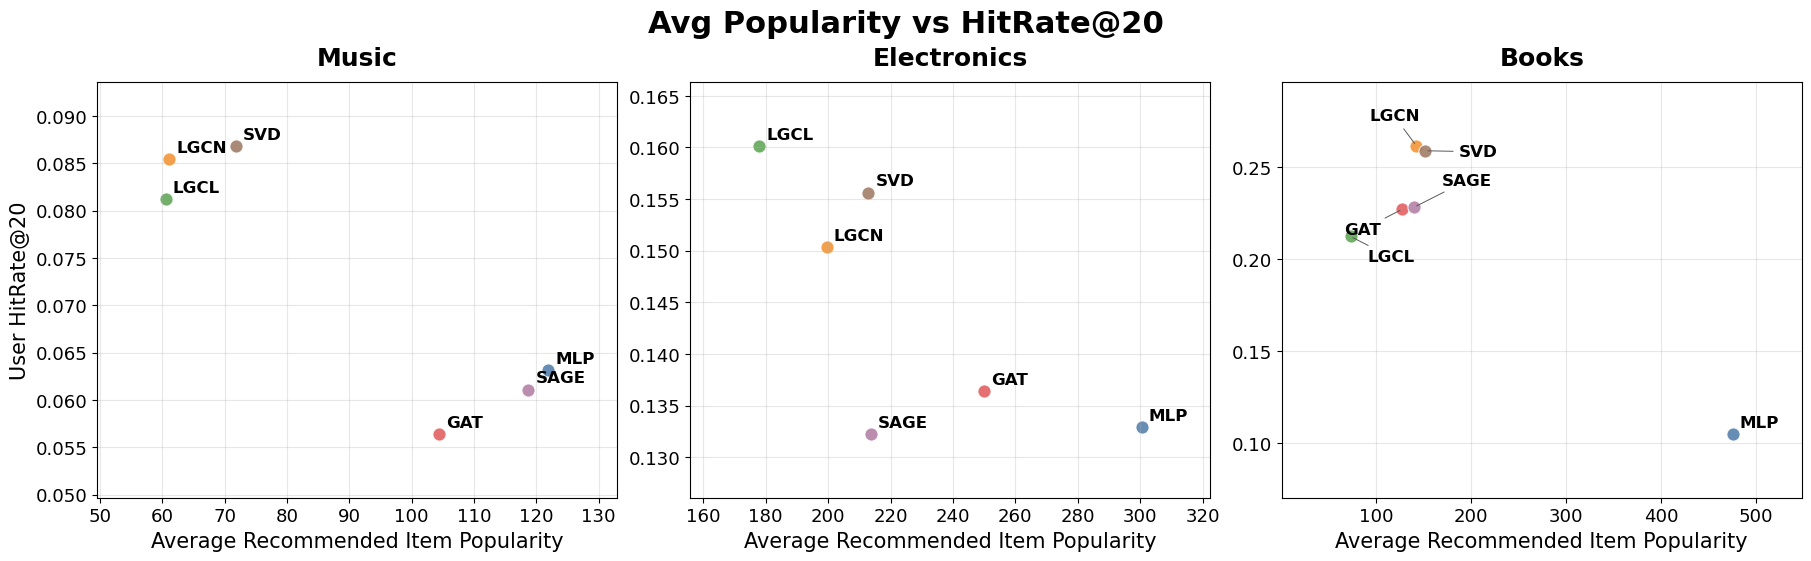

In [41]:
behavior_records = [
    # Books
    {'Dataset': 'Books', 'Model': 'MLP Two Tower', 'Short': 'MLP', 'HitRate@20': 0.104738, 'AvgRecommendedPopularity': 475.655988},
    {'Dataset': 'Books', 'Model': 'LightGCN', 'Short': 'LGCN', 'HitRate@20': 0.261787, 'AvgRecommendedPopularity': 142.660362},
    {'Dataset': 'Books', 'Model': 'LightGCL', 'Short': 'LGCL', 'HitRate@20': 0.212409, 'AvgRecommendedPopularity': 73.472865},
    {'Dataset': 'Books', 'Model': 'GATv2', 'Short': 'GAT', 'HitRate@20': 0.227305, 'AvgRecommendedPopularity': 128.034958},
    {'Dataset': 'Books', 'Model': 'GraphSAGE', 'Short': 'SAGE', 'HitRate@20': 0.228360, 'AvgRecommendedPopularity': 140.326988},
    {'Dataset': 'Books', 'Model': 'SVD Graph Fusion', 'Short': 'SVD', 'HitRate@20': 0.259090, 'AvgRecommendedPopularity': 152.128794},

    # Electronics
    {'Dataset': 'Electronics', 'Model': 'MLP Two Tower', 'Short': 'MLP', 'HitRate@20': 0.132887, 'AvgRecommendedPopularity': 300.437633},
    {'Dataset': 'Electronics', 'Model': 'LightGCN', 'Short': 'LGCN', 'HitRate@20': 0.150353, 'AvgRecommendedPopularity': 199.530896},
    {'Dataset': 'Electronics', 'Model': 'LightGCL', 'Short': 'LGCL', 'HitRate@20': 0.160164, 'AvgRecommendedPopularity': 177.908569},
    {'Dataset': 'Electronics', 'Model': 'GATv2', 'Short': 'GAT', 'HitRate@20': 0.136381, 'AvgRecommendedPopularity': 249.950334},
    {'Dataset': 'Electronics', 'Model': 'GraphSAGE', 'Short': 'SAGE', 'HitRate@20': 0.132219, 'AvgRecommendedPopularity': 213.583274},
    {'Dataset': 'Electronics', 'Model': 'SVD Graph Fusion', 'Short': 'SVD', 'HitRate@20': 0.155630, 'AvgRecommendedPopularity': 212.890242},

    # Music Instruments
    {'Dataset': 'Music Instruments', 'Model': 'MLP Two Tower', 'Short': 'MLP', 'HitRate@20': 0.063142, 'AvgRecommendedPopularity': 121.905476},
    {'Dataset': 'Music Instruments', 'Model': 'LightGCN', 'Short': 'LGCN', 'HitRate@20': 0.085470, 'AvgRecommendedPopularity': 61.101067},
    {'Dataset': 'Music Instruments', 'Model': 'LightGCL', 'Short': 'LGCL', 'HitRate@20': 0.081230, 'AvgRecommendedPopularity': 60.566720},
    {'Dataset': 'Music Instruments', 'Model': 'GATv2', 'Short': 'GAT', 'HitRate@20': 0.056384, 'AvgRecommendedPopularity': 104.363380},
    {'Dataset': 'Music Instruments', 'Model': 'GraphSAGE', 'Short': 'SAGE', 'HitRate@20': 0.061088, 'AvgRecommendedPopularity': 118.750139},
    {'Dataset': 'Music Instruments', 'Model': 'SVD Graph Fusion', 'Short': 'SVD', 'HitRate@20': 0.086861, 'AvgRecommendedPopularity': 71.753833},
]

behavior_df = pd.DataFrame(behavior_records)

short_to_model = {
    'MLP': 'MLP Two Tower',
    'LGCN': 'LightGCN',
    'LGCL': 'LightGCL',
    'GAT': 'GATv2',
    'SAGE': 'GraphSAGE',
    'SVD': 'SVD Graph Fusion',
}

scatter_datasets = ['Music Instruments', 'Electronics', 'Books']
label_offsets = {
    ('Books', 'LGCN'): (-34, 18),
    ('Books', 'SVD'): (24, -4),
    ('Books', 'GAT'): (-42, -18),
    ('Books', 'SAGE'): (20, 16),
    ('Books', 'LGCL'): (12, -18),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=False, constrained_layout=True)

for ax, dataset in zip(axes, scatter_datasets):
    dataset_df = behavior_df[behavior_df['Dataset'] == dataset]
    for _, row in dataset_df.iterrows():
        ax.scatter(
            row['AvgRecommendedPopularity'],
            row['HitRate@20'],
            s=90,
            color=model_colors[row['Model']],
            edgecolor='white',
            linewidth=0.8,
            alpha=0.85,
        )
        xytext = label_offsets.get((dataset, row['Short']), (5, 5))
        arrowprops = None if xytext == (5, 5) else {'arrowstyle': '-', 'color': '0.35', 'lw': 0.7}
        ax.annotate(
            row['Short'],
            (row['AvgRecommendedPopularity'], row['HitRate@20']),
            xytext=xytext,
            textcoords='offset points',
            fontsize=12,
            fontweight='bold',
            arrowprops=arrowprops,
        )

    ax.set_title(dataset_labels[dataset], fontsize=18, fontweight='bold', pad=12)
    ax.set_xlabel('Average Recommended Item Popularity', fontsize=15)
    ax.tick_params(axis='both', labelsize=13)
    ax.grid(True, alpha=0.3)
    ax.margins(x=0.18, y=0.22)

axes[0].set_ylabel('User HitRate@20', fontsize=15)
fig.suptitle('Avg Popularity vs HitRate@20', fontsize=22, fontweight='bold')
fig.savefig(results_dir / 'avg_popularity_vs_hitrate20.pdf', bbox_inches='tight', dpi=600)
fig.savefig(results_dir / 'avg_popularity_vs_hitrate20.png', bbox_inches='tight', dpi=600)
plt.show()

##### Training Efficiency / Early Stopping Summary

In [42]:
training_records = [
    # Books
    {'Dataset': 'Books', 'Model': 'SVD Graph Fusion', 'SelectedTrial': 'rank256_top100_w0075_lr125_reg5e-4', 'EpochsRan': 100, 'BestEpoch': 99, 'BestValNDCG@20': 0.044917, 'BestValRecall@20': 0.068343, 'EarlyStopped': False, 'TrainingTimeSec': 1503.302577},
    {'Dataset': 'Books', 'Model': 'MLP Two Tower', 'SelectedTrial': 'emb256_h512-256_lr5e-4_reg1e-4', 'EpochsRan': 25, 'BestEpoch': 15, 'BestValNDCG@20': 0.010836, 'BestValRecall@20': 0.015807, 'EarlyStopped': True, 'TrainingTimeSec': 711.283068},
    {'Dataset': 'Books', 'Model': 'LightGCN', 'SelectedTrial': 'emb128_l2_lr1e-3_reg1e-4', 'EpochsRan': 100, 'BestEpoch': 100, 'BestValNDCG@20': 0.044880, 'BestValRecall@20': 0.067649, 'EarlyStopped': False, 'TrainingTimeSec': 1111.985590},
    {'Dataset': 'Books', 'Model': 'LightGCL', 'SelectedTrial': 'book_r100_cl002_lr5e-4', 'EpochsRan': 11, 'BestEpoch': 1, 'BestValNDCG@20': 0.038009, 'BestValRecall@20': 0.054110, 'EarlyStopped': True, 'TrainingTimeSec': 113.367430},
    {'Dataset': 'Books', 'Model': 'GATv2', 'SelectedTrial': 'emb128_l2_h4_lr1e-3_drop0', 'EpochsRan': 37, 'BestEpoch': 27, 'BestValNDCG@20': 0.036750, 'BestValRecall@20': 0.055250, 'EarlyStopped': True, 'TrainingTimeSec': 1726.982008},
    {'Dataset': 'Books', 'Model': 'GraphSAGE', 'SelectedTrial': 'emb256_h256_l2_drop01_lr5e-4', 'EpochsRan': 54, 'BestEpoch': 44, 'BestValNDCG@20': 0.035564, 'BestValRecall@20': 0.053328, 'EarlyStopped': True, 'TrainingTimeSec': 913.342793},

    # Electronics
    {'Dataset': 'Electronics', 'Model': 'MLP Two Tower', 'SelectedTrial': 'emb128_h256-128_lr1e-3_reg1e-4', 'EpochsRan': 15, 'BestEpoch': 5, 'BestValNDCG@20': 0.024402, 'BestValRecall@20': 0.047841, 'EarlyStopped': True, 'TrainingTimeSec': 321.460037},
    {'Dataset': 'Electronics', 'Model': 'LightGCN', 'SelectedTrial': 'emb128_l3_lr1e-3_reg1e-4', 'EpochsRan': 46, 'BestEpoch': 36, 'BestValNDCG@20': 0.036222, 'BestValRecall@20': 0.073514, 'EarlyStopped': True, 'TrainingTimeSec': 501.025296},
    {'Dataset': 'Electronics', 'Model': 'LightGCL', 'SelectedTrial': 'elec_r100_cl002_lr5e-4', 'EpochsRan': 26, 'BestEpoch': 16, 'BestValNDCG@20': 0.038156, 'BestValRecall@20': 0.075979, 'EarlyStopped': True, 'TrainingTimeSec': 213.195711},
    {'Dataset': 'Electronics', 'Model': 'GATv2', 'SelectedTrial': 'emb128_l2_h2_lr5e-4_drop0', 'EpochsRan': 20, 'BestEpoch': 10, 'BestValNDCG@20': 0.028412, 'BestValRecall@20': 0.055042, 'EarlyStopped': True, 'TrainingTimeSec': 438.897725},
    {'Dataset': 'Electronics', 'Model': 'GraphSAGE', 'SelectedTrial': 'emb128_h128_l2_drop02_lr5e-4', 'EpochsRan': 29, 'BestEpoch': 19, 'BestValNDCG@20': 0.029496, 'BestValRecall@20': 0.059002, 'EarlyStopped': True, 'TrainingTimeSec': 313.464777},
    {'Dataset': 'Electronics', 'Model': 'SVD Graph Fusion', 'SelectedTrial': 'rank64_top10_w002_reg5e-4', 'EpochsRan': 100, 'BestEpoch': 100, 'BestValNDCG@20': 0.036558, 'BestValRecall@20': 0.074078, 'EarlyStopped': False, 'TrainingTimeSec': 1106.171383},

    # Music Instruments
    {'Dataset': 'Music Instruments', 'Model': 'LightGCN', 'SelectedTrial': 'emb128_l3_lr1e-3_reg1e-4', 'EpochsRan': 43, 'BestEpoch': 33, 'BestValNDCG@20': 0.045399, 'BestValRecall@20': 0.103117, 'EarlyStopped': True, 'TrainingTimeSec': 652.539867},
    {'Dataset': 'Music Instruments', 'Model': 'LightGCL', 'SelectedTrial': 'fixed_n2_r5_tau05_cl02', 'EpochsRan': 95, 'BestEpoch': 85, 'BestValNDCG@20': 0.041119, 'BestValRecall@20': 0.092430, 'EarlyStopped': True, 'TrainingTimeSec': 909.213701},
    {'Dataset': 'Music Instruments', 'Model': 'SVD Graph Fusion', 'SelectedTrial': 'rank64_top10_w005_reg5e-4', 'EpochsRan': 100, 'BestEpoch': 100, 'BestValNDCG@20': 0.045283, 'BestValRecall@20': 0.103427, 'EarlyStopped': False, 'TrainingTimeSec': 1438.658766},
    {'Dataset': 'Music Instruments', 'Model': 'GraphSAGE', 'SelectedTrial': 'emb256_h256_l2_drop02_lr5e-4', 'EpochsRan': 19, 'BestEpoch': 9, 'BestValNDCG@20': 0.027332, 'BestValRecall@20': 0.058521, 'EarlyStopped': True, 'TrainingTimeSec': 258.646044},
    {'Dataset': 'Music Instruments', 'Model': 'GATv2', 'SelectedTrial': 'emb128_l2_h4_lr5e-4_drop0', 'EpochsRan': 22, 'BestEpoch': 12, 'BestValNDCG@20': 0.023921, 'BestValRecall@20': 0.053372, 'EarlyStopped': True, 'TrainingTimeSec': 249.507937},
    {'Dataset': 'Music Instruments', 'Model': 'MLP Two Tower', 'SelectedTrial': 'emb128_h256-128_lr1e-3_reg1e-4', 'EpochsRan': 13, 'BestEpoch': 3, 'BestValNDCG@20': 0.027447, 'BestValRecall@20': 0.061095, 'EarlyStopped': True, 'TrainingTimeSec': 333.106931},
]

training_summary_df = pd.DataFrame(training_records)
training_summary_df['TrainingTimeMin'] = training_summary_df['TrainingTimeSec'] / 60

training_display_df = training_summary_df[
    [
        'Dataset', 'Model', 'SelectedTrial', 'EpochsRan', 'BestEpoch',
        'BestValNDCG@20', 'BestValRecall@20', 'EarlyStopped',
        'TrainingTimeSec', 'TrainingTimeMin',
    ]
].sort_values(['Dataset', 'TrainingTimeSec'], ascending=[True, True])

training_display_df.style.format({
    'BestValNDCG@20': '{:.4f}',
    'BestValRecall@20': '{:.4f}',
    'TrainingTimeSec': '{:.1f}',
    'TrainingTimeMin': '{:.1f}',
})

,Dataset,Model,SelectedTrial,EpochsRan,BestEpoch,BestValNDCG@20,BestValRecall@20,EarlyStopped,TrainingTimeSec,TrainingTimeMin
3,Books,LightGCL,book_r100_cl002_lr5e-4,11,1,0.0380,0.0541,True,113.4,1.9
1,Books,MLP Two Tower,emb256_h512-256_lr5e-4_reg1e-4,25,15,0.0108,0.0158,True,711.3,11.9
5,Books,GraphSAGE,emb256_h256_l2_drop01_lr5e-4,54,44,0.0356,0.0533,True,913.3,15.2
2,Books,LightGCN,emb128_l2_lr1e-3_reg1e-4,100,100,0.0449,0.0676,False,1112.0,18.5
0,Books,SVD Graph Fusion,rank256_top100_w0075_lr125_reg5e-4,100,99,0.0449,0.0683,False,1503.3,25.1
4,Books,GATv2,emb128_l2_h4_lr1e-3_drop0,37,27,0.0367,0.0553,True,1727.0,28.8
8,Electronics,LightGCL,elec_r100_cl002_lr5e-4,26,16,0.0382,0.0760,True,213.2,3.6
10,Electronics,GraphSAGE,emb128_h128_l2_drop02_lr5e-4,29,19,0.0295,0.0590,True,313.5,5.2
6,Electronics,MLP Two Tower,emb128_h256-128_lr1e-3_reg1e-4,15,5,0.0244,0.0478,True,321.5,5.4
9,Electronics,GATv2,emb128_l2_h2_lr5e-4_drop0,20,10,0.0284,0.0550,True,438.9,7.3


##### Dataset Filtering and Split Summary

In [43]:
dataset_setup_records = [
    {
        'Dataset': 'Musical Instruments',
        'Rating Filter': 'rating >= 3.0',
        'K-core': '3-core',
        'Interactions after filter': 442_627,
        'Interactions after k-core': 70_570,
        'Users': 15_093,
        'Items': 8_054,
        'Train': 35_489,
        'Val': 15_810,
        'Test': 19_271,
    },
    {
        'Dataset': 'Electronics',
        'Rating Filter': 'rating >= 3.0',
        'K-core': '10-core',
        'Interactions after filter': 6_466_395,
        'Interactions after k-core': 234_521,
        'Users': 13_455,
        'Items': 8_360,
        'Train': 154_810,
        'Val': 27_588,
        'Test': 52_123,
    },
    {
        'Dataset': 'Books',
        'Rating Filter': 'rating >= 3.0',
        'K-core': '30-core',
        'Interactions after filter': 20_411_733,
        'Interactions after k-core': 581_415,
        'Users': 8_526,
        'Items': 9_165,
        'Train': 400_627,
        'Val': 61_106,
        'Test': 119_682,
    },
]

dataset_setup_df = pd.DataFrame(dataset_setup_records)
dataset_setup_df['Train / Val / Test'] = dataset_setup_df.apply(
    lambda row: f"{row['Train']:,} / {row['Val']:,} / {row['Test']:,}",
    axis=1,
)

dataset_setup_display_df = dataset_setup_df[
    [
        'Dataset', 'Rating Filter', 'K-core',
        'Interactions after filter', 'Interactions after k-core',
        'Users', 'Items', 'Train / Val / Test',
    ]
]

dataset_setup_display_df.style.format({
    'Interactions after filter': '{:,}',
    'Interactions after k-core': '{:,}',
    'Users': '{:,}',
    'Items': '{:,}',
})

,Dataset,Rating Filter,K-core,Interactions after filter,Interactions after k-core,Users,Items,Train / Val / Test
0,Musical Instruments,rating >= 3.0,3-core,"442,627","70,570","15,093","8,054","35,489 / 15,810 / 19,271"
1,Electronics,rating >= 3.0,10-core,"6,466,395","234,521","13,455","8,360","154,810 / 27,588 / 52,123"
2,Books,rating >= 3.0,30-core,"20,411,733","581,415","8,526","9,165","400,627 / 61,106 / 119,682"


##### Training Curves: Loss and NDCG@20

Model,MLP Two Tower,LightGCN,LightGCL,GATv2,GraphSAGE,SVD Graph Fusion
Dataset,,,,,,
Books,25,100,11,37,54,100
Electronics,15,46,26,20,29,100
Music Instruments,13,43,95,22,19,100


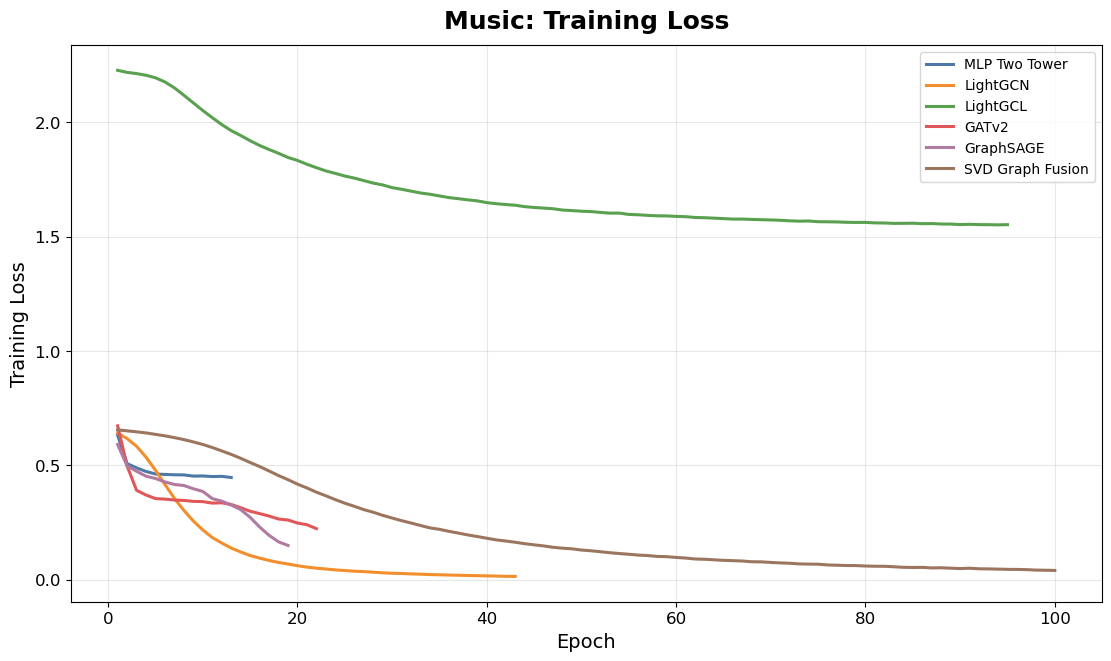

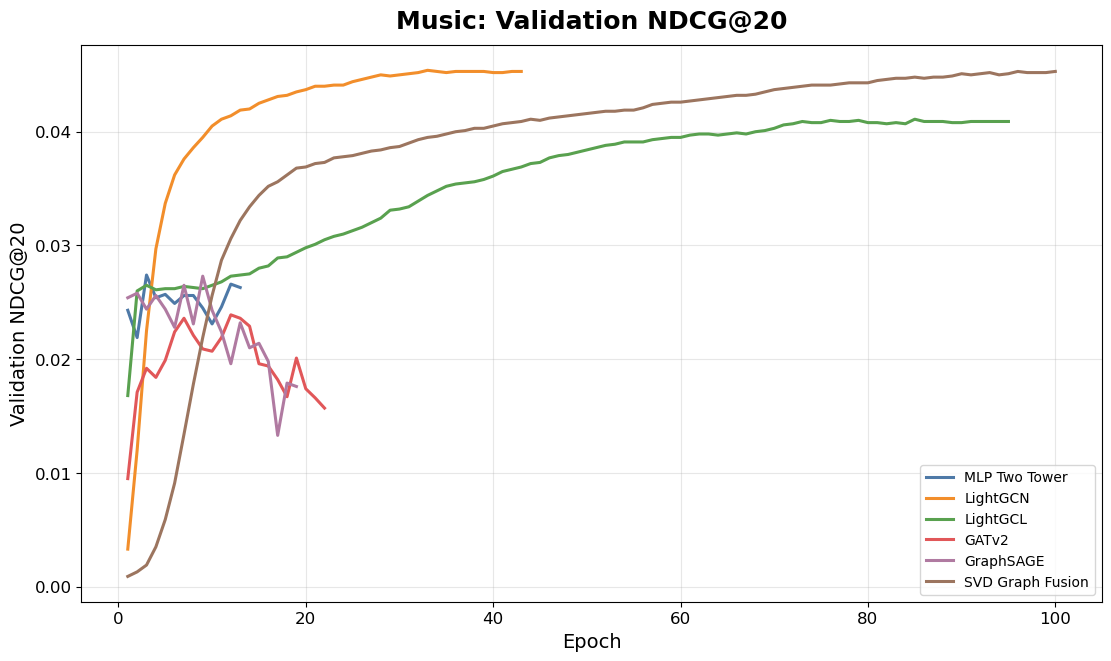

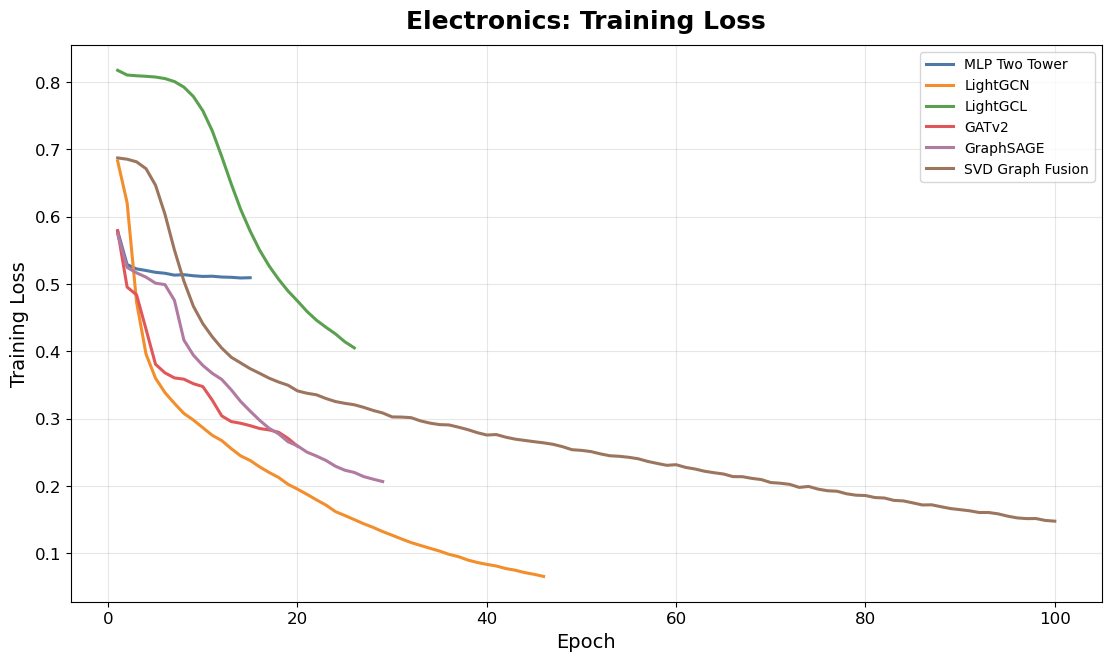

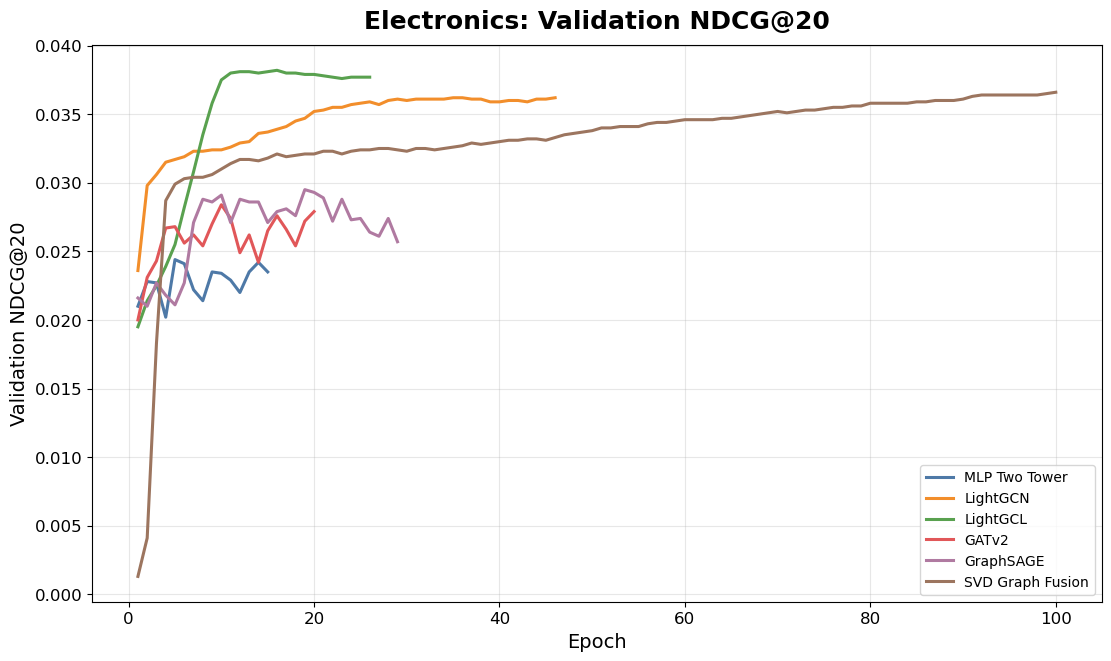

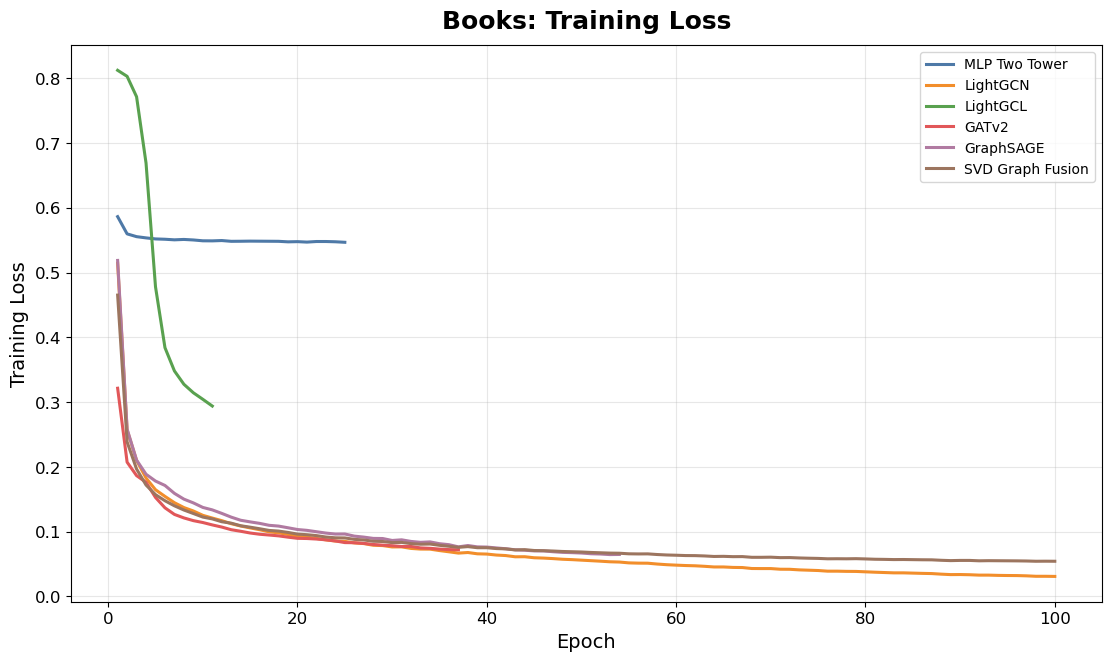

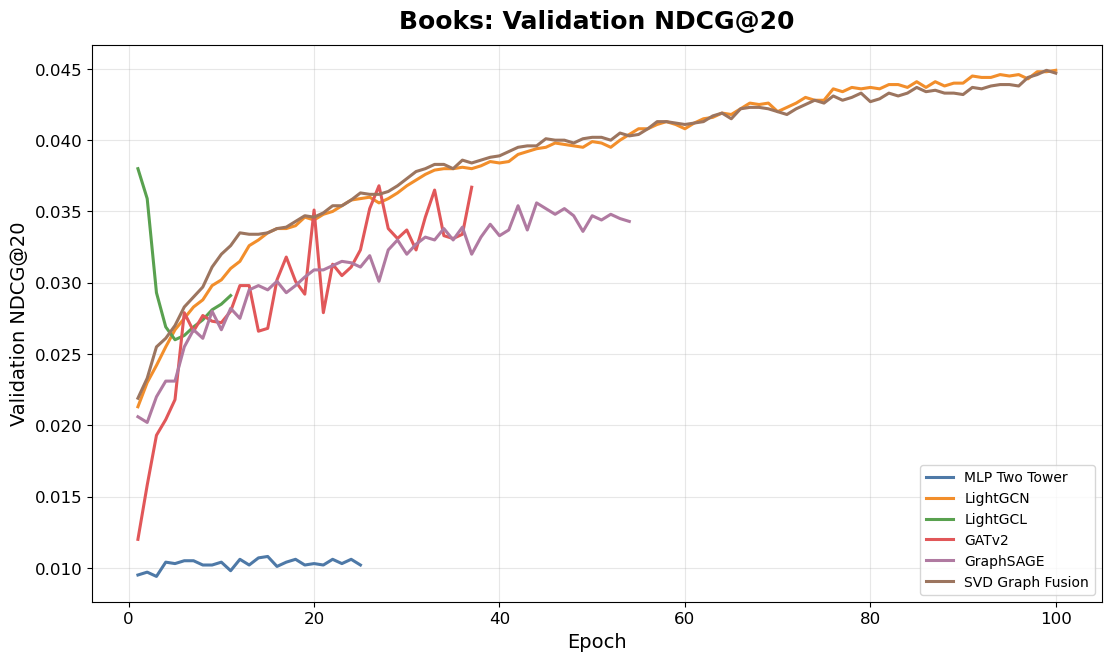

In [45]:
import json
import re
from IPython.display import display

training_curve_notebooks = {
    'Books': Path('Final_Books.ipynb'),
    'Electronics': Path('Final_Electronics.ipynb'),
    'Music Instruments': Path('Final_Music_Instruments.ipynb'),
}

curve_dataset_labels = {
    'Books': 'Books',
    'Electronics': 'Electronics',
    'Music Instruments': 'Music',
}

curve_model_order = [
    'MLP Two Tower',
    'LightGCN',
    'LightGCL',
    'GATv2',
    'GraphSAGE',
    'SVD Graph Fusion',
]

epoch_pattern = re.compile(
    r'Epoch\s+(?P<epoch>\d+)\s+\|\s+loss=(?P<loss>[0-9.]+)\s+\|\s+R@20=(?P<recall>[0-9.]+)\s+\|\s+N@20=(?P<ndcg>[0-9.]+)'
)

def _infer_training_model(cell_source):
    if 'Training SVD Graph Fusion' in cell_source:
        return 'SVD Graph Fusion'
    if 'Training GraphSAGE' in cell_source:
        return 'GraphSAGE'
    if 'Training GATv2' in cell_source:
        return 'GATv2'
    if 'Training LightGCL' in cell_source:
        return 'LightGCL'
    if 'class LightGCN' in cell_source:
        return 'LightGCN'
    if 'class TwoTowerMLP' in cell_source:
        return 'MLP Two Tower'
    return None

def _collect_output_text(cell):
    chunks = []
    for output in cell.get('outputs', []):
        if 'text' in output:
            chunks.append(''.join(output['text']))
        data = output.get('data', {})
        if 'text/plain' in data:
            chunks.append(''.join(data['text/plain']))
    return '\n'.join(chunks)

def load_training_curves(notebook_path, dataset_name):
    notebook = json.loads(notebook_path.read_text(encoding='utf-8'))
    rows = []
    for cell in notebook['cells']:
        source = ''.join(cell.get('source', []))
        model = _infer_training_model(source)
        if model is None:
            continue
        output_text = _collect_output_text(cell)
        for match in epoch_pattern.finditer(output_text):
            rows.append({
                'Dataset': dataset_name,
                'Model': model,
                'Epoch': int(match.group('epoch')),
                'Loss': float(match.group('loss')),
                'Recall@20': float(match.group('recall')),
                'NDCG@20': float(match.group('ndcg')),
            })
    return rows

curve_rows = []
for dataset_name, notebook_path in training_curve_notebooks.items():
    curve_rows.extend(load_training_curves(notebook_path, dataset_name))

training_curves_df = pd.DataFrame(curve_rows)
display(training_curves_df.groupby(['Dataset', 'Model']).size().unstack(fill_value=0).reindex(columns=curve_model_order))

def plot_training_curve(dataset_name, metric, ylabel, filename_stub):
    fig, ax = plt.subplots(figsize=(11, 6.5), constrained_layout=True)
    dataset_df = training_curves_df[training_curves_df['Dataset'] == dataset_name]
    for model in curve_model_order:
        model_df = dataset_df[dataset_df['Model'] == model].sort_values('Epoch')
        if model_df.empty:
            continue
        ax.plot(
            model_df['Epoch'],
            model_df[metric],
            label=model,
            color=model_colors[model],
            linewidth=2.2,
        )

    ax.set_title(f"{curve_dataset_labels[dataset_name]}: {ylabel}", fontsize=18, fontweight='bold', pad=12)
    ax.set_xlabel('Epoch', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=10, frameon=True)
    fig.savefig(results_dir / f'{filename_stub}_{dataset_name.lower().replace(" ", "_")}.pdf', bbox_inches='tight', dpi=600)
    fig.savefig(results_dir / f'{filename_stub}_{dataset_name.lower().replace(" ", "_")}.png', bbox_inches='tight', dpi=600)
    plt.show()

for dataset_name in ['Music Instruments', 'Electronics', 'Books']:
    plot_training_curve(dataset_name, 'Loss', 'Training Loss', 'training_loss_curves')
    plot_training_curve(dataset_name, 'NDCG@20', 'Validation NDCG@20', 'validation_ndcg20_curves')
